1) Introducción y preguntas

In [2]:
import pandas as pd
import numpy as np

2) Carga de datos

In [4]:
df = pd.read_csv('data/world_bank_data_2025.csv')

# Visualización inicial
df.head()
df.shape
df.info()
df.columns


<class 'pandas.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_name                     3472 non-null   str    
 1   country_id                       3472 non-null   str    
 2   year                             3472 non-null   int64  
 3   Inflation (CPI %)                2694 non-null   float64
 4   GDP (Current USD)                2933 non-null   float64
 5   GDP per Capita (Current USD)     2938 non-null   float64
 6   Unemployment Rate (%)            2795 non-null   float64
 7   Interest Rate (Real, %)          1735 non-null   float64
 8   Inflation (GDP Deflator, %)      2904 non-null   float64
 9   GDP Growth (% Annual)            2912 non-null   float64
 10  Current Account Balance (% GDP)  2563 non-null   float64
 11  Government Expense (% of GDP)    1820 non-null   float64
 12  Government Revenue (% of GDP)  

Index(['country_name', 'country_id', 'year', 'Inflation (CPI %)',
       'GDP (Current USD)', 'GDP per Capita (Current USD)',
       'Unemployment Rate (%)', 'Interest Rate (Real, %)',
       'Inflation (GDP Deflator, %)', 'GDP Growth (% Annual)',
       'Current Account Balance (% GDP)', 'Government Expense (% of GDP)',
       'Government Revenue (% of GDP)', 'Tax Revenue (% of GDP)',
       'Gross National Income (USD)', 'Public Debt (% of GDP)'],
      dtype='str')

3) Limpieza

In [35]:
# Identificación de nombres dentro del df
interes = ['Argentina', 'Brazil', 'Chile', 'Uruguay', 'Bolivia', 'Colombia', 'Peru', 'Ecuador', 'Mexico', 'United States', 'Spain']
encontrados = [p for p in df['country_name'].unique() if p in interes]
print(f"Encontrados: {encontrados}")

# y para ver cuáles NO encontró (si falta alguno):
no_encontrados = [p for p in interes if p not in df['country_name'].unique()]
print(f"No encontrados: {no_encontrados}")

Encontrados: ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'Spain', 'Mexico', 'Peru', 'Uruguay', 'United States']
No encontrados: []


In [5]:
# Tomo los países a analizar
paises_sudamerica = ['Argentina', 'Brazil', 'Chile', 'Uruguay', 'Bolivia', 'Colombia', 'Peru', 'Ecuador']

df_sudamerica = df[df['country_name'].isin(paises_sudamerica)]

df_sudamerica.shape
df_sudamerica.head()

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
96,Argentina,ar,2010,NaN,4.236274e+11,10260.131311,7.714,-8.566029,20.915124,10.125398,-0.383119,NaN,21.241316,12.853043,4.091925e+11,NaN
97,Argentina,ar,2011,NaN,5.301581e+11,12704.283182,7.180,-7.773405,23.703472,6.003952,-1.007281,NaN,20.196408,12.663628,5.150045e+11,NaN
98,Argentina,ar,2012,NaN,5.459824e+11,12949.717487,7.217,-6.748196,22.314881,-1.026420,-0.391595,NaN,21.182235,12.952842,5.330736e+11,NaN
99,Argentina,ar,2013,NaN,5.520251e+11,12963.675773,7.100,-5.485839,23.948798,2.405324,-2.377496,NaN,21.565283,12.452903,5.401857e+11,NaN
100,Argentina,ar,2014,NaN,5.263197e+11,12233.144412,7.268,-11.600699,40.282972,-2.512615,-1.744002,24.569781,22.332294,12.610967,5.155322e+11,NaN


In [6]:
# Busco valores faltantes
df_sudamerica.isna().sum()

# Analizo si los valores faltantes se deben a un período de tiempo específico
df_sudamerica.groupby('year')['GDP (Current USD)'].apply(lambda x: x.isna().sum())

# Filtro años 2024 y 2025 ya que están vacíos y visualizo cambios en el dataset
df_sudamerica = df_sudamerica[df_sudamerica['year'] <= 2023]
df_sudamerica.head(15)
df_sudamerica.isna().sum()

# Visualizo 'Inflation (CPI %)' ya que contiene muchos valores nulos
df_sudamerica[df_sudamerica['Inflation (CPI %)'].isna()][['country_name', 'year']]

# Actualizo el dataset con datos del Banco Mundial sobre Argentina
inflacion_ar = {
    2018: 34.28, 2019: 53.55, 2020: 42.02,
    2021: 48.41, 2022: 72.43, 2023: 133.49
}

for anio, valor in inflacion_ar.items():
    mask = (df_sudamerica['country_name'] == 'Argentina') & (df_sudamerica['year'] == anio)
    df_sudamerica.loc[mask, 'Inflation (CPI %)'] = valor

df_sudamerica[df_sudamerica['country_name'] == 'Argentina'][['year', 'Inflation (CPI %)']]
df_sudamerica.head(15)


,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
96,Argentina,ar,2010,NaN,4.236274e+11,10260.131311,7.714,-8.566029,20.915124,10.125398,-0.383119,NaN,21.241316,12.853043,4.091925e+11,NaN
97,Argentina,ar,2011,NaN,5.301581e+11,12704.283182,7.180,-7.773405,23.703472,6.003952,-1.007281,NaN,20.196408,12.663628,5.150045e+11,NaN
98,Argentina,ar,2012,NaN,5.459824e+11,12949.717487,7.217,-6.748196,22.314881,-1.026420,-0.391595,NaN,21.182235,12.952842,5.330736e+11,NaN
99,Argentina,ar,2013,NaN,5.520251e+11,12963.675773,7.100,-5.485839,23.948798,2.405324,-2.377496,NaN,21.565283,12.452903,5.401857e+11,NaN
100,Argentina,ar,2014,NaN,5.263197e+11,12233.144412,7.268,-11.600699,40.282972,-2.512615,-1.744002,24.569781,22.332294,12.610967,5.155322e+11,NaN
101,Argentina,ar,2015,NaN,5.947493e+11,13679.626498,7.579,-1.314709,26.579992,2.731160,-2.962927,25.008393,22.149080,12.336507,5.836155e+11,NaN
102,Argentina,ar,2016,NaN,5.575323e+11,12699.962314,8.085,-7.006040,41.119380,-2.080328,-2.709222,26.179916,21.256701,12.097284,5.452516e+11,NaN
103,Argentina,ar,2017,NaN,6.436284e+11,14532.500931,8.347,0.455893,26.006379,2.818503,-4.839959,24.282532,19.337124,10.939624,6.272005e+11,NaN
104,Argentina,ar,2018,34.280000,5.248199e+11,11752.799892,9.220,4.564409,42.033669,-2.617396,-5.160553,22.687781,17.702448,9.992390,5.060940e+11,NaN
105,Argentina,ar,2019,53.550000,4.477547e+11,9955.974787,9.843,12.103970,49.195579,-2.000861,-0.779998,22.036481,18.736300,10.594398,4.301668e+11,NaN


In [8]:
# Me quedo con los datos relevantes para el análisis y visualizo
columnas_relevantes = [
    'country_name', 'year',
    'GDP (Current USD)',
    'GDP per Capita (Current USD)',
    'GDP Growth (% Annual)',
    'Inflation (CPI %)',
    'Unemployment Rate (%)'
]

df_final = df_sudamerica[columnas_relevantes].copy()
df_final.isna().sum()
df_final.head(15)

,country_name,year,GDP (Current USD),GDP per Capita (Current USD),GDP Growth (% Annual),Inflation (CPI %),Unemployment Rate (%)
96,Argentina,2010,4.236274e+11,10260.131311,10.125398,NaN,7.714
97,Argentina,2011,5.301581e+11,12704.283182,6.003952,NaN,7.180
98,Argentina,2012,5.459824e+11,12949.717487,-1.026420,NaN,7.217
99,Argentina,2013,5.520251e+11,12963.675773,2.405324,NaN,7.100
100,Argentina,2014,5.263197e+11,12233.144412,-2.512615,NaN,7.268
101,Argentina,2015,5.947493e+11,13679.626498,2.731160,NaN,7.579
102,Argentina,2016,5.575323e+11,12699.962314,-2.080328,NaN,8.085
103,Argentina,2017,6.436284e+11,14532.500931,2.818503,NaN,8.347
104,Argentina,2018,5.248199e+11,11752.799892,-2.617396,34.280000,9.220
105,Argentina,2019,4.477547e+11,9955.974787,-2.000861,53.550000,9.843


In [18]:
# Agrego datos faltantes de los años 2024-2025 extraidos del FMI
df_fmi = pd.read_csv('datos_fmi_listo_para_merge.csv')

# Marcar el origen de cada fila, para no perder de vista que 2024-2025 vienen de otra fuente
df_final['fuente'] = 'World Bank (2010-2023)'
df_fmi['fuente'] = 'FMI (2024-2025)'

df_final_completo = pd.concat([df_final, df_fmi], ignore_index=True)
df_final_completo = df_final_completo.sort_values(['country_name', 'year']).reset_index(drop=True)


4) Estadística descriptiva

In [19]:
# Panorama general
print(df_final_completo.describe())

# Creo un resumen por país con estadísticos importantes sobre cada indicador
resumen_por_pais = df_final_completo.groupby('country_name')[
    ['GDP per Capita (Current USD)', 'GDP Growth (% Annual)', 'Inflation (CPI %)', 'Unemployment Rate (%)']
].agg(['mean', 'std', 'min', 'max'])

resumen_por_pais

              year  GDP (Current USD)  GDP per Capita (Current USD)  \
count   136.000000       1.350000e+02                    135.000000   
mean   2017.823529       4.665264e+11                   9917.313707   
std       4.672825       6.509086e+11                   4984.629445   
min    2010.000000       1.964972e+10                   1929.783731   
25%    2014.000000       8.076850e+10                   6232.516976   
50%    2018.000000       2.540422e+11                   8535.599380   
75%    2022.000000       4.220657e+11                  13664.739272   
max    2025.000000       2.616156e+12                  23576.271000   

       GDP Growth (% Annual)  Inflation (CPI %)  Unemployment Rate (%)  
count             135.000000         128.000000             136.000000  
mean                2.534232          10.448799               6.845221  
std                 4.028393          26.457770               2.866542  
min               -10.933307          -0.338872               2.0210

GDP per Capita (Current USD)                             \
                                     mean          std           min   
country_name                                                           
Argentina                    12525.339278  1738.583351   8535.599380   
Bolivia                       3338.585555   781.116713   1929.783731   
Brazil                       10245.895754  1730.766438   7074.193783   
Chile                        15168.086992  1470.224109  12632.870473   
Colombia                      7009.697560   938.354626   5339.687114   
Ecuador                       6118.333042   659.526700   4520.309590   
Peru                          6997.648123  1141.712506   5072.114940   
Uruguay                      18436.023956  2942.685277  12641.057685   

                           GDP Growth (% Annual)                       \
                       max                  mean       std        min   
country_name                                                            
Argentina     14532.500931              1.132172  5.139284  -9.900485   
Bolivia        5106.530000              2.983968  3.726673  -8.737884   
Brazil        13396.624357              1.808780  2.932794  -3.545763   
Chile         17734.761000              2.711007  3.611972  -6.143475   
Colombia       8622.574000              3.150389  3.748222  -7.185914   
Ecuador        7198.575000              2.885744  4.564732  -9.245096   
Peru           9910.942000              3.297981  4.906052 -10.933307   
Uruguay       23576.271000              2.289411  3.409094  -7.380142   

                        Inflation (CPI %)                                    \
                    max              mean        std        min         max   
country_name                                                                  
Argentina     10.441812         86.608889  62.890369  34.280000  219.900000   
Bolivia        6.796011          4.483816   4.465159   0.737384   19.500000   
Brazil         7.528226          5.741904   2.028363   3.211768    9.280106   
Chile         11.333957          4.239608   2.573952   1.410711   11.643867   
Colombia      10.801198          5.216952   3.220073   2.016992   11.735904   
Ecuador        9.818418          2.086589   1.743025  -0.338872    5.101722   
Peru          13.355230          3.509619   1.907832   1.500000    8.333706   
Uruguay        7.803410          7.543053   1.584828   4.700000    9.756406   

             Unemployment Rate (%)                           
                              mean       std    min     max  
country_name                                                 
Argentina                 7.846706  1.358425  6.100  11.461  
Bolivia                   3.501176  1.380871  2.021   7.903  
Brazil                    9.363824  2.595674  6.000  13.697  
Chile                     7.835882  1.277359  6.074  10.934  
Colombia                 10.163941  1.996207  8.000  15.983  
Ecuador                   3.810882  0.734552  3.083   6.127  
Peru                      4.399882  1.364507  3.208   7.179  
Uruguay                   7.839471  1.097938  6.307  10.413

In [20]:
# Análisis de volatilidad (desvío estándar) de indicadores a través de los años analizados
volatilidad = df_final_completo.groupby('country_name')[
    ['GDP Growth (% Annual)', 'Inflation (CPI %)', 'Unemployment Rate (%)']
].std().sort_values('Inflation (CPI %)', ascending=False)

volatilidad

,GDP Growth (% Annual),Inflation (CPI %),Unemployment Rate (%)
country_name,,,
Argentina,5.139284,62.890369,1.358425
Bolivia,3.726673,4.465159,1.380871
Colombia,3.748222,3.220073,1.996207
Chile,3.611972,2.573952,1.277359
Brazil,2.932794,2.028363,2.595674
Peru,4.906052,1.907832,1.364507
Ecuador,4.564732,1.743025,0.734552
Uruguay,3.409094,1.584828,1.097938


In [21]:
# Recalculo los promedios de inflación sobre el período 2018-2025 ya que Argentina no tiene datos previos
inflacion_2018_2025 = df_final_completo[df_final_completo['year'] >= 2018].groupby('country_name')['Inflation (CPI %)'].mean().sort_values(ascending=False)
inflacion_2018_2025

country_name
Argentina    86.608889
Uruguay       7.040703
Colombia      6.455380
Chile         5.276449
Brazil        5.198325
Bolivia       4.145883
Peru          3.891630
Ecuador       1.102016
Name: Inflation (CPI %), dtype: float64

## Preguntas
1. ¿Cómo evolucionó el PBI (o PBI per cápita) de Argentina entre 2010 y 2025, comparado con Brasil, Chile y Uruguay?
2. ¿En qué años tuvo Argentina los picos de inflación más altos, y cómo se compara esa inflación con el promedio de Sudamérica en esos mismos años?
3. ¿Cuál fue la tasa de desempleo de Argentina antes y después de la pandemia (2019 vs. 2021-2022), y cómo se compara ese "salto" con el de otros países de la región?
4. De los indicadores disponibles (PBI, inflación, desempleo), ¿cuál mostró mayor volatilidad en Argentina en comparación con el resto de Sudamérica?
5. Tomando todo lo anterior, ¿la economía argentina se movió "en sintonía" con la región sudamericana en la última década, o tuvo una dinámica más aislada/divergente?

5) Visualizaciones

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

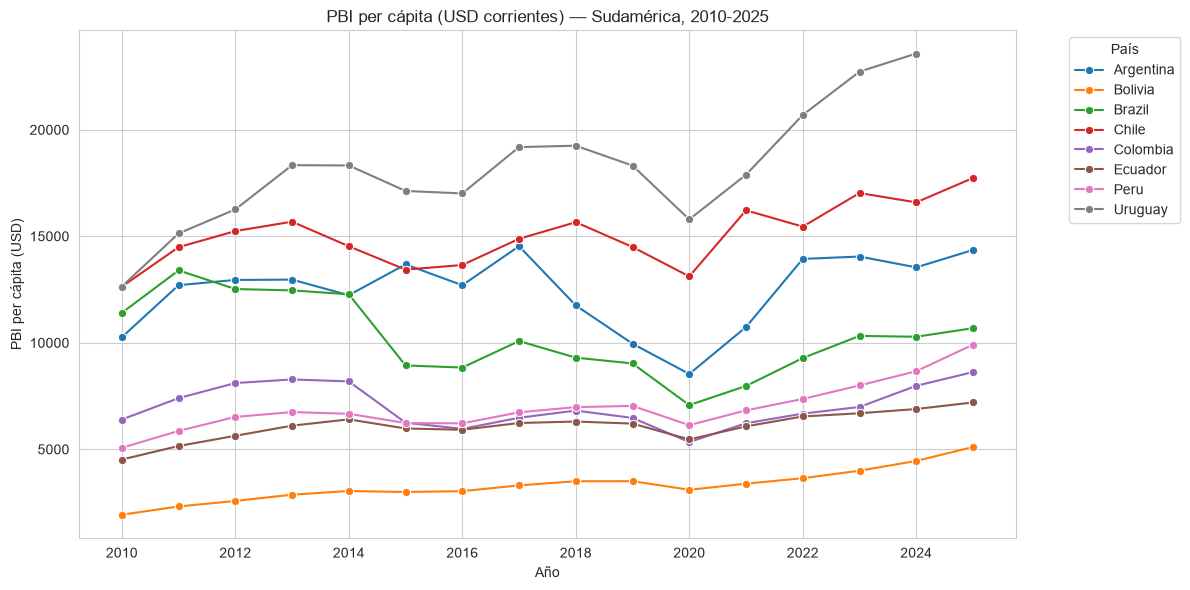

In [24]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_final_completo,
    x='year',
    y='GDP per Capita (Current USD)',
    hue='country_name',
    marker='o'
)

plt.title('PBI per cápita (USD corrientes) — Sudamérica, 2010-2025')
plt.xlabel('Año')
plt.ylabel('PBI per cápita (USD)')
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

6) Análisis por pregunta

## Preguntas
1. ¿Cómo evolucionó el PBI (o PBI per cápita) de Argentina entre 2010 y 2025, comparado con Brasil, Chile y Uruguay?
2. ¿En qué años tuvo Argentina los picos de inflación más altos, y cómo se compara esa inflación con el promedio de Sudamérica en esos mismos años?
3. ¿Cuál fue la tasa de desempleo de Argentina antes y después de la pandemia (2019 vs. 2021-2022), y cómo se compara ese "salto" con el de otros países de la región?
4. De los indicadores disponibles (PBI, inflación, desempleo), ¿cuál mostró mayor volatilidad en Argentina en comparación con el resto de Sudamérica?
5. Tomando todo lo anterior, ¿la economía argentina se movió "en sintonía" con la región sudamericana en la última década, o tuvo una dinámica más aislada/divergente?

7) Conclusiones

# 